# Browse Evaluation Results

Load any eval log from the `logs/` directory, view metadata, macro metrics, per-type breakdown, and individual samples.

In [20]:
import json
import pandas as pd
from pathlib import Path
from datetime import datetime
import ipywidgets as widgets
from IPython.display import display, HTML

LOGS_DIR = Path('../logs')

## 1. Discover Eval Logs

Scans `logs/` for evaluation output files, sorted by newest first.

In [21]:
def discover_logs():
    files = []
    for p in sorted(LOGS_DIR.glob('*.out.*'), key=lambda x: x.stat().st_mtime, reverse=True):
        try:
            with open(p) as f:
                first = json.loads(f.readline())
            if 'experiment_name' in first:
                files.append({
                    'path': p,
                    'name': p.name,
                    'mtime': datetime.fromtimestamp(p.stat().st_mtime),
                    'size_mb': p.stat().st_size / (1024*1024),
                    'model': first.get('model_name', '?'),
                    'dataset': first.get('dataset', '?'),
                    'dataset_config': first.get('dataset_config', ''),
                    'split': first.get('dataset_split', '?'),
                    'date': first.get('date', '?'),
                    'prompt': first.get('prompt', '?'),
                    'batch_size': first.get('batch_size', '?'),
                    'unconstrained': first.get('unconstrained_generation', False),
                })
            else:
                # enriched files (no experiment_name header)
                files.append({
                    'path': p,
                    'name': p.name,
                    'mtime': datetime.fromtimestamp(p.stat().st_mtime),
                    'size_mb': p.stat().st_size / (1024*1024),
                    'model': first.get('model_name', '?'),
                    'dataset': first.get('dataset', '?'),
                    'dataset_config': first.get('dataset_config', ''),
                    'split': first.get('dataset_split', '?'),
                    'date': first.get('date', '?'),
                    'prompt': '?',
                    'batch_size': '?',
                    'unconstrained': False,
                })
        except Exception as e:
            pass
    return files

logs = discover_logs()
print(f"Found {len(logs)} eval logs")

df_logs = pd.DataFrame(logs)
df_logs['model_short'] = df_logs['model'].apply(lambda x: x.split('/')[-1] if len(x) > 40 else x)
df_logs['dataset_short'] = df_logs['dataset'].apply(lambda x: x.split('/')[-1] if '/' in x else x)

display(df_logs[['name', 'model_short', 'dataset_short', 'split', 'size_mb', 'mtime']].style.format({
    'size_mb': '{:.1f}M',
    'mtime': '{:%m-%d %H:%M}',
}))

Found 17 eval logs


,name,model_short,dataset_short,split,size_mb,mtime
0,twowiki_test_sft.out.1,sft_merged,2WikiMultihopQA,validation,173.9M,06-29 10:01
1,mintaka_test_sft_en.out.0,sft_merged,mintaka,test,36.1M,06-29 10:01
2,twowiki_test_sft.out.0,sft_merged,2WikiMultihopQA,validation,1.3M,06-25 09:00
3,mintaka_test_sft.out.0,sft_merged,mintaka,test,0.8M,06-25 09:00
4,twowikimultihop_train_eval.out.0,Qwen/Qwen3.6-35B-A3B,2WikiMultihopQA,train,409.3M,06-24 11:40
5,mintaka_train_eval_qwen36_35b.out.0.enriched,Qwen/Qwen3.6-35B-A3B,mintaka-qa-en,train,110.4M,06-22 20:23
6,mintaka_test_eval_qwen36_35b.out.3.enriched,Qwen/Qwen3.6-35B-A3B,mintaka-qa-en,test,31.4M,06-22 20:23
7,mintaka_test_eval_qwen35_2b.out.0.enriched,Qwen/Qwen3.5-2B,mintaka-qa-en,test,0.0M,06-22 20:23
8,mintaka_train_eval_qwen35_2b.out.0.enriched,Qwen/Qwen3.5-2B,mintaka-qa-en,train,0.0M,06-22 20:21
9,mintaka_train_eval_qwen36_35b.out.0,Qwen/Qwen3.6-35B-A3B,mintaka-qa-en,train,110.0M,06-22 10:42


In [23]:
# --- Select a log file ---
log_options = {f"{l['name']}  ({l['dataset'].split('/')[-1]}, {l['split']})": i for i, l in enumerate(logs)}
log_selector = widgets.Dropdown(
    options=log_options,
    description='Log:',
    style={'description_width': 'initial'},
    layout={'width': '800px'}
)
display(log_selector)

Dropdown(description='Log:', layout=Layout(width='800px'), options={'twowiki_test_sft.out.1  (2WikiMultihopQA,…

In [24]:
idx = log_selector.value
selected = logs[idx]
print(f"Selected: {selected['name']}")
print()

# Load header, samples, macro
with open(selected['path']) as f:
    header = json.loads(f.readline())
    
    samples = []
    macro = None
    for line in f:
        line = line.strip()
        if not line:
            continue
        obj = json.loads(line)
        if 'macro_precision' in obj:
            macro = obj
        elif 'input_sample' in obj:
            samples.append(obj)

print(f"Samples: {len(samples)}")
print(f"Macro metrics: {'found' if macro else 'NOT FOUND'}")

# Determine type field
dataset_name = selected['dataset']
if '2Wiki' in dataset_name or '2wiki' in dataset_name:
    TYPE_FIELD = 'type'
elif 'mintaka' in dataset_name.lower():
    TYPE_FIELD = 'complexityType'
else:
    TYPE_FIELD = 'complexityType'  # default

Selected: twowiki_test_sft.out.1

Samples: 12576
Macro metrics: found


## 2. Metadata

In [25]:
def fmt_model(m):
    parts = m.split('/')
    return '/'.join(parts[-2:]) if len(parts) > 1 else m

meta_items = [
    ('Experiment', header.get('experiment_name')),
    ('Model', fmt_model(header.get('model_name', ''))),
    ('Dataset', header.get('dataset')),
    ('Dataset config', header.get('dataset_config', '—')),
    ('Split', header.get('dataset_split')),
    ('Date', header.get('date')),
    ('Prompt', header.get('prompt')),
    ('Batch size', header.get('batch_size')),
    ('Beam search', header.get('num_beams')),
    ('Unconstrained', header.get('unconstrained_generation', False)),
    ('Total samples', len(samples)),
]

html = '<table style="font-size:14px">'
for k, v in meta_items:
    html += f'<tr><td style="font-weight:bold;padding-right:20px">{k}</td><td>{v}</td></tr>'
html += '</table>'
display(HTML(html))

Experiment,twowiki_test_sft
Model,ripo631h-quokka/sft_merged
Dataset,xanhho/2WikiMultihopQA
Dataset config,—
Split,validation
Date,26/06/2026 11:21:05 UTC
Prompt,prompts/prompt_qwen36_mini2.txt
Batch size,16
Beam search,1
Unconstrained,False
Total samples,12576


## 3. Macro Metrics

In [26]:
if macro:
    cols = {
        'macro_precision': 'Precision',
        'macro_recall': 'Recall',
        'macro_f1': 'F1',
        'macro_correct_accuracy': 'Accuracy',
        'macro_dont_know': 'DontKnow',
        'macro_answered_precision': 'Ans Precision',
        'macro_answered_recall': 'Ans Recall',
        'macro_answered_f1': 'Ans F1',
        'macro_answered_accuracy': 'Ans Accuracy',
    }
    row = {v: f"{macro[k]*100:.1f}%" for k, v in cols.items()}
    df_macro = pd.DataFrame([row], index=['All'])
    display(df_macro.style.set_caption('Macro Metrics'))
else:
    print("No macro metrics found in this log.")

,Precision,Recall,F1,Accuracy,DontKnow,Ans Precision,Ans Recall,Ans F1,Ans Accuracy
All,50.2%,50.2%,50.2%,50.2%,0.4%,50.4%,50.4%,50.4%,50.4%


## 4. Per-Type Metrics

In [27]:
def per_type_metrics(samples, type_field):
    by_type = {}
    for s in samples:
        t = str(s['input_sample'].get(type_field, 'unknown'))
        if t not in by_type:
            by_type[t] = []
        by_type[t].append(s)
    
    rows = []
    for t, group in sorted(by_type.items()):
        n = len(group)
        n_correct = sum(1 for s in group if s['evaluation']['correct'] == 1)
        n_dk = sum(1 for s in group if s['evaluation'].get('dont_know') == 1)
        avg_f1 = sum(s['evaluation']['f1'] for s in group) / n
        avg_prec = sum(s['evaluation']['precision'] for s in group) / n
        avg_rec = sum(s['evaluation']['recall'] for s in group) / n
        rows.append({
            'type': t,
            'count': n,
            'correct': n_correct,
            'accuracy': f'{n_correct/n*100:.1f}%',
            'avg_f1': f'{avg_f1:.4f}',
            'avg_precision': f'{avg_prec:.4f}',
            'avg_recall': f'{avg_rec:.4f}',
            'dont_know': n_dk,
        })
    return pd.DataFrame(rows)

df_type = per_type_metrics(samples, TYPE_FIELD)
display(df_type.style.set_caption(f'Per-Type Metrics ({TYPE_FIELD})'))

# Overall stats
total_correct = sum(1 for s in samples if s['evaluation']['correct'] == 1)
total_dk = sum(1 for s in samples if s['evaluation'].get('dont_know') == 1)
print(f"\nCorrect: {total_correct}/{len(samples)} ({total_correct/len(samples)*100:.1f}%)")
print(f"DontKnow: {total_dk}/{len(samples)} ({total_dk/len(samples)*100:.1f}%)")
print(f"Type field used: {TYPE_FIELD}")

,type,count,correct,accuracy,avg_f1,avg_precision,avg_recall,dont_know
0,bridge_comparison,2751,1748,63.5%,0.6354,0.6354,0.6354,3
1,comparison,3040,1959,64.4%,0.6444,0.6444,0.6444,20
2,compositional,5236,2047,39.1%,0.3909,0.3909,0.3909,26
3,inference,1549,556,35.9%,0.3589,0.3589,0.3589,1



Correct: 6310/12576 (50.2%)
DontKnow: 50/12576 (0.4%)
Type field used: type


## 5. Browse Samples

Filter by correctness and type, then view individual samples.

In [31]:
# --- Filters ---
unique_types = sorted(set(str(s['input_sample'].get(TYPE_FIELD, 'unknown')) for s in samples))

filter_correct = widgets.Dropdown(
    options=[('All', 'all'), ('Correct only', 'correct'), ('Wrong only', 'wrong'), ('DontKnow', 'dont_know')],
    value='all',
    description='Filter:',
)
filter_type = widgets.Dropdown(
    options=['all'] + unique_types,
    value='all',
    description='Type:',
)
show_count = widgets.IntSlider(value=5, min=1, max=50, description='Show:')
display(widgets.HBox([filter_correct, filter_type, show_count]))

In [33]:
def filter_samples(samples, correct_filter, type_filter):
    result = []
    for s in samples:
        if correct_filter == 'correct' and s['evaluation']['correct'] != 1:
            continue
        if correct_filter == 'wrong' and s['evaluation']['correct'] != 0:
            continue
        if correct_filter == 'dont_know' and s['evaluation'].get('dont_know') != 1:
            continue
        if type_filter != 'all' and str(s['input_sample'].get(TYPE_FIELD, 'unknown')) != type_filter:
            continue
        result.append(s)
    return result

filtered = filter_samples(samples, filter_correct.value, filter_type.value)
print(f"Showing {min(len(filtered), show_count.value)} of {len(filtered)} samples")

rows = []
for s in filtered[:show_count.value]:
    t = s['input_sample'].get(TYPE_FIELD, '?')
    cat = s['input_sample'].get('category', '')
    ev = s['evaluation']
    rows.append({
        'question': s['question'][:100],
        'gt_answer': s['gt_answer'],
        'prediction': s['prediction'],
        'f1': ev['f1'],
        'correct': ev['correct'],
        'dont_know': ev.get('dont_know', 0),
        TYPE_FIELD: t,
        'category': cat,
        'triples': len(s.get('triples', [])),
    })

df_samples = pd.DataFrame(rows)
display(df_samples.style.set_caption('Filtered Samples'))

Showing 5 of 50 samples


,question,gt_answer,prediction,f1,correct,dont_know,type,category,triples
0,"Which film came out earlier, I Am Breathing or Ulti Ganga?",Ulti Ganga,"[""I don't know.""]",0,0,1,comparison,,2
1,Where does the director of film The Marquise Of O (Film) work at?,Cahiers du cinéma,"[""I don't know.""]",0,0,1,compositional,,3
2,What is the place of birth of the director of film Double Or Nothing (1940 Film)?,"New Brunswick, New Jersey","[""I don't know.""]",0,0,1,compositional,,6
3,Why did the director of film Normande (Film) die?,Parkinson's disease,"[""I don't know.""]",0,0,1,compositional,,2
4,"Which film has the director who was born later, The Night The Prowler or When The Gods Fall Asleep?",The Night The Prowler,"[""I don't know.""]",0,0,1,bridge_comparison,,8


### Sample Detail

Enter the row index (0-based) from the table above to see the full output.

In [34]:
sample_idx = widgets.BoundedIntText(value=0, min=0, max=len(filtered)-1, description='Row:')
show_triples = widgets.Checkbox(value=False, description='Show triples')
display(widgets.HBox([sample_idx, show_triples]))

In [35]:
if len(filtered) == 0:
    print("No samples match the filters.")
else:
    idx = min(sample_idx.value, len(filtered)-1)
    s = filtered[idx]
    
    print(f"Question: {s['question']}")
    print(f"Ground truth: {s['gt_answer']}")
    print(f"Prediction: {s['prediction']}")
    print(f"F1: {s['evaluation']['f1']}  |  Precision: {s['evaluation']['precision']}  |  Recall: {s['evaluation']['recall']}")
    print(f"Correct: {s['evaluation']['correct']}  |  DontKnow: {s['evaluation'].get('dont_know')}")
    print(f"Type: {s['input_sample'].get(TYPE_FIELD, '?')}  |  Category: {s['input_sample'].get('category', '-')}")
    print()
    print("=" * 60)
    print("FULL GENERATION")
    print("=" * 60)
    print(s['full_prediction'])
    
    if show_triples.value and s.get('triples'):
        print()
        print("=" * 60)
        print(f"GENERATED TRIPLES ({len(s['triples'])})")
        print("=" * 60)
        for t in s['triples']:
            print(f"  {t}")

Question: Which film came out earlier, I Am Breathing or Ulti Ganga?
Ground truth: Ulti Ganga
Prediction: ["I don't know."]
F1: 0  |  Precision: 0.0  |  Recall: 0.0
Correct: 0  |  DontKnow: 1
Type: comparison  |  Category: -

FULL GENERATION
Reasoning: To determine which film came out earlier, I need to find the release dates for both "I Am Breathing" and "Ulti Ganga".

Fact: <I Am Breathing> <genre> <Documentary film> .
I need the release date for "I Am Breathing".
Fact: <I Am Breathing> <genre> <Biographical film> .
I need the release date for "I Am Breathing".
I need to retrieve the release date for "I Am Breathing".
Answer: ["I don't know."]


## 6. Distribution Charts

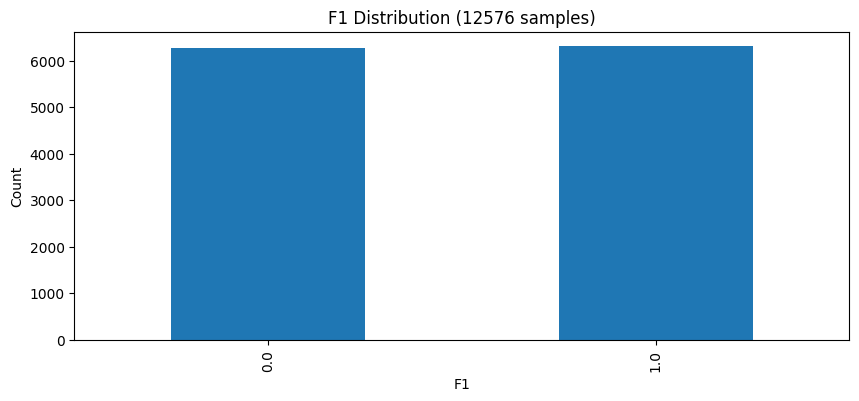

In [36]:
# F1 distribution
f1_vals = [s['evaluation']['f1'] for s in samples]
pd.Series(f1_vals).value_counts().sort_index().plot(
    kind='bar',
    title=f'F1 Distribution ({len(samples)} samples)',
    figsize=(10, 4),
    xlabel='F1',
    ylabel='Count'
);